# 📏 LAB TOOLS — Tratamento de Dados Experimentais
---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramente realiza o **tratamento de dados experimentais** calculando, para cada grandeza medida:

1. Valor médio: $$\bar{x}=\frac{1}{N}\sum_{i=1}^N x_i$$
2. Desvio-padrão amostral: $$s=\sqrt{\frac{1}{N-1}\sum_{i=1}^N (x_i-\bar{x})^2}$$
3. Desvio-padrão da média: $$s(\bar{x})=\frac{s}{\sqrt{N}}$$
4. Incerteza residual associada à resolução $r$ do instrumento de medição: $$u_r=\frac{r}{2}$$
5. Incerteza-padrão: $$u_p=\sqrt{(s(\bar{x}))^2 + u_r^2}$$

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo. Você pode carregar os dados de um arquivo ou inseri-los manualmente.

---
### Formatos de arquivo aceitos

| Formato | Extensão |
|---|---|
| XLSX - Planilha do Excel | `.xlsx` |
| CSV - Valores separados por vírgula | `.csv` `.txt` |


Nomes de grandeza com sinais diacríticos como **acentos, cedilha ou til** (`posição`, `força`, `ângulo` ou `pressão`, por exemplo) são aceitos.

No formato `XLSX`, cada grandeza deve ocupar uma coluna da planilha e os valores numéricos podem usar `.` ou `,` como separador decimal.

Para indicar as unidades das grandezas medidas e as resoluções dos instrumentos de medição, use as palavras-chave `#unidades:` e `#resoluções:` seguidas de valores separados por `,` ou por `;`.

As informações sobre unidades e resoluções devem estar obrigatoriamente nas células `A1` e `A2`, respectivamente, antes da linha que contém os nomes ou símbolos das grandezas medidas:

|   |    A                         | B       | C     |
|:--|:------                       |:--------|:------|
| 1 | #unidades: kg, m, s          |         |       |     
| 2 | #resolucoes: 0.01, 0.1, 0.01 |         |       |    
| 3 | massa                        | posição | tempo |
| 4 | 10.0                         | 15.2    | 3.41  |     

No formato `CSV`, os valores devem ser separados por `,` ou por `;`. Os valores numéricos podem usar `.` ou `,` como separador decimal. Se usar `,` como separador decimal, use `;` como separador de valores, para evitar ambiguidade.

As unidades das grandezas medidas e as resoluções dos instrumentos de medição podem ser informadas em linhas de comentários (iniciadas com `#`), antes da linha de cabeçalho, que deve conter os nomes ou símbolos das grandezas.

Para indicar unidades e resoluções, use as palavras-chave `#unidades:` e `#resolucoes:` no início das linhas, seguidas de valores separados por `,` ou por `;`:

```
 #unidades: kg, m, s
 #resolucoes: 0.01, 0.1, 0.01
 massa, posição, tempo
 10.0, 15.2, 3.41
 ...
```

Se estas linhas estiverem ausentes, unidades e resoluções poderão ser
preenchidas manualmente em campos que aparecerão após o carregamento do arquivo.

---
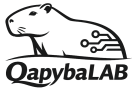

**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **LAB TOOLS &mdash; Tratamento de Dados Experimentais**
# ── Célula 1: tratamento de dados experimentais ───────────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo modelos, métodos,
# pacotes a serem usados e linhas gerais da inteface gráfica, mas a maior parte
# do código, especialmente as funções para leitura de arquivos e para a
# interface gráfica, foi escrita usando o modelo Claude Sonnet 4.6.
# O código gerado foi inspecionado e sofreu diversas alterações e correções
# realizadas pelo licenciante e pelo modelo Gemini 3.5-flash.

import math, io, base64, re, unicodedata, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as w
from IPython.display import display, HTML, clear_output

# openpyxl é necessário para leitura de xlsx
try:
    import openpyxl
    _XLSX_OK = True
except ImportError:
    _XLSX_OK = False

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10,
                             "axes.spines.top": False,
                             "axes.spines.right": False})

# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS
#  Convenção compartilhada por toda a suíte LAB/NEWTON TOOLS:
#    .sec   → rótulo de seção (cor = acento do app)
#    .rcard → card de resultado/destaque (cor = acento do app)
#    .gcard → card de "sucesso" (verde fixo)
#    .bcard → card informativo secundário (azul fixo)
#    .wcard → card de aviso (laranja fixo)
#    .ecard → card de erro (vermelho fixo)
#    .icard → card informativo auxiliar (violeta fixo)
#    .res-t → tabela de dados (cabeçalho azul-marinho fixo)
#  Acento desta ferramenta: verde #2f9e44
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#2f9e44;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.bcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.res-t{border-collapse:collapse;font-size:.83rem;width:40%;margin:6px 0;}
.res-t th{background:#1a1a2e;color:#fff;padding:5px 10px;text-align:left;}
.res-t td{padding:4px 10px;text-align:left;border-bottom:1px solid #eee;
  font-family:monospace;}
.res-t tr:nth-child(odd) td{text-align:left}
.res-t tr:nth-child(even) td{background:#eafcff;text-align:left}
.sum-t{border-collapse:collapse;font-size:.85rem;width:70%;margin:6px 0;}
.sum-t th{background:#2f9e44;color:#fff;padding:5px 10px;text-align:left;}
.sum-t td{padding:5px 10px;text-align:left;border-bottom:1px solid #ddd;
  font-family:monospace;}
.sum-t tr:nth-child(odd) td{text-align:left}
.sum-t tr:nth-child(even) td{background:#f0fff4;}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  UTILITÁRIOS
# ══════════════════════════════════════════════════════════════════

def nome_para_arquivo(nome):
    """
    Converte nome com acentos/cedilha para versão segura para nomes
    de arquivo (ex: 'posição' → 'posicao').
    """
    nfd = unicodedata.normalize("NFD", nome)
    return "".join(c for c in nfd
                   if unicodedata.category(c) != "Mn"
                   ).replace(" ", "_")

# ══════════════════════════════════════════════════════════════════
#  MATEMÁTICA
# ══════════════════════════════════════════════════════════════════
def calcular(medicoes, resolucao):
    n     = len(medicoes)
    media = np.mean(medicoes)
    s     = np.std(medicoes, ddof=1)
    s_med = s / math.sqrt(n)
    u_r   = resolucao / 2
    u_p   = math.sqrt(s_med**2 + u_r**2)
    return dict(n=n, media=float(media), s=float(s),
                s_med=float(s_med), u_r=float(u_r), u_p=float(u_p))

def fmt_dec(resolucao, extra=2):
    if resolucao >= 1:
        return extra
    return max(1, -int(math.floor(math.log10(resolucao)))) + extra

def fmt(v, dec):
    return f"{v:.{dec}f}"

# ══════════════════════════════════════════════════════════════════
#  LEITURA DE ARQUIVO
#
#  Formatos suportados: CSV / TSV / TXT e XLSX
#
#  Metadados opcionais (CSV/TXT):
#    # unidades:   kg, m, s
#    # resolucoes: 0.01, 0.1, 0.01
#
#  Metadados opcionais (XLSX):
#    Célula A1: "# unidades: kg, m, s"   (texto na primeira coluna)
#    Célula A2: "# resolucoes: 0.01, 0.1, 0.01"
#    As demais linhas com "#" na coluna A também são tratadas como comentários.
#
#  Palavras-chave aceitas (maiúsculas/minúsculas/acentos indiferentes):
#    unidades / unidade / units / unit
#    resolucoes / resolução / resoluções / resolucao / resolution / resolutions
#
#  Nomes de grandeza com acentos e cedilha são aceitos normalmente
#  (ex: posição, temperatura, força, ângulo).
# ══════════════════════════════════════════════════════════════════
_RE_UNID = re.compile(
    r"#\s*(?:unidades?|units?)\s*:\s*(.+)", re.IGNORECASE)
_RE_RES  = re.compile(
    r"#\s*(?:resolu[cç][oõ]es?|resolutions?)\s*:\s*(.+)", re.IGNORECASE)

def _parse_lista(texto):
    """Divide uma string por vírgulas ou ponto-e-vírgulas."""
    return [t.strip() for t in re.split(r"[,;]", texto) if t.strip()]

def detectar_sep(texto):
    cnt = {",": 0, ";": 0, "\t": 0}
    for l in texto.splitlines()[:15]:
        s = l.strip()
        if not s or s.startswith("#"): continue
        for sep in cnt: cnt[sep] += s.count(sep)
    best = max(cnt, key=cnt.get)
    return best if cnt[best] > 0 else " "

def _extrair_meta_comentarios(linhas_comentario):
    """Extrai unidades e resoluções das linhas de comentário."""
    meta = {"unidades": None, "resolucoes": None}
    for s in linhas_comentario:
        m_u = _RE_UNID.match(s)
        if m_u:
            meta["unidades"] = _parse_lista(m_u.group(1))
            continue
        m_r = _RE_RES.match(s)
        if m_r:
            vals = _parse_lista(m_r.group(1))
            res_parsed = []
            for v in vals:
                try:
                    res_parsed.append(float(v.replace(",", ".")))
                except ValueError:
                    res_parsed.append(None)
            meta["resolucoes"] = res_parsed
    return meta

def ler_arquivo(texto, sep):
    """Lê CSV/TSV/TXT. Retorna (meta, cab, colunas, erros)."""
    comentarios = []
    for linha in texto.splitlines():
        s = linha.strip()
        if not s: continue
        if s.startswith("#"):
            comentarios.append(s)
        else:
            break   # termina bloco de comentários

    meta = _extrair_meta_comentarios(comentarios)

    linhas = [l for l in texto.splitlines()
              if l.strip() and not l.strip().startswith("#")]
    if not linhas:
        return meta, [], [], ["Arquivo sem dados."]

    def split(l):
        return ([p.strip() for p in l.split(sep)]
                if sep != " " else l.split())

    primeira = split(linhas[0])
    tem_cab  = any(not t.replace(",","").replace(".","",1)
                   .lstrip("-").isdigit()
                   for t in primeira if t)
    if tem_cab:
        cab    = [t.strip() for t in primeira]
        linhas = linhas[1:]
    else:
        cab = []

    n_col   = len(split(linhas[0])) if linhas else 0
    colunas = [[] for _ in range(n_col)]
    erros   = []
    for i, linha in enumerate(linhas, 1):
        partes = split(linha)
        for j in range(n_col):
            try:
                v = float(partes[j].replace(",",".")) if j < len(partes) else None
                if v is not None:
                    colunas[j].append(v)
            except ValueError:
                erros.append(f"Linha {i}, col {j+1}: "
                             f"'{partes[j] if j<len(partes) else '?'}'")

    return meta, cab, colunas, erros

def ler_xlsx(conteudo_bytes):
    """
    Lê um arquivo XLSX e retorna (meta, cab, colunas, erros).

    Convenção de metadados no XLSX:
      Linhas cujo valor na 1ª célula começa com "#" são tratadas
      como comentários (mesma sintaxe do CSV):
        Célula A1: "# unidades: kg, m, s"
        Célula A2: "# resolucoes: 0.01, 0.1, 0.01"
      Essas linhas são ignoradas nos dados numéricos.

    Cabeçalho: primeira linha não-comentário que contém texto
    (não conversível para float) na maioria das células.

    Nomes de grandeza com acentos e cedilha são preservados
    diretamente do conteúdo das células.
    """
    if not _XLSX_OK:
        return {}, [], [], ["openpyxl não instalado. "
                            "Execute: pip install openpyxl"]
    try:
        wb = openpyxl.load_workbook(
            io.BytesIO(conteudo_bytes), data_only=True)
    except Exception as e:
        return {}, [], [], [f"Erro ao abrir XLSX: {e}"]

    ws = wb.active

    # Coleta todas as linhas como listas de strings/valores
    todas_linhas = []
    for row in ws.iter_rows(values_only=True):
        # Ignora linhas completamente vazias
        if all(v is None for v in row):
            continue
        todas_linhas.append([
            str(v).strip() if v is not None else "" for v in row])

    if not todas_linhas:
        return {}, [], [], ["Planilha vazia."]

    # ── Separa comentários (linhas cuja 1ª célula começa com "#") ─
    comentarios  = []
    dados_linhas = []
    for linha in todas_linhas:
        primeira_cel = linha[0] if linha else ""
        if primeira_cel.startswith("#"):
            comentarios.append(primeira_cel)
        else:
            dados_linhas.append(linha)

    meta = _extrair_meta_comentarios(comentarios)

    if not dados_linhas:
        return meta, [], [], ["Nenhuma linha de dados encontrada."]

    n_col = len(dados_linhas[0])

    # ── Detecta cabeçalho ─────────────────────────────────────────
    def eh_numero(s):
        try:
            float(s.replace(",", "."))
            return True
        except ValueError:
            return False

    primeira = dados_linhas[0]
    tem_cab  = any(not eh_numero(t) for t in primeira if t)
    if tem_cab:
        # Preserva nomes com acentos/cedilha diretamente
        cab          = [t for t in primeira]
        dados_linhas = dados_linhas[1:]
    else:
        cab = []

    # ── Transpõe: linhas → colunas ────────────────────────────────
    colunas = [[] for _ in range(n_col)]
    erros   = []
    for i, linha in enumerate(dados_linhas, 1):
        for j in range(n_col):
            cel = linha[j] if j < len(linha) else ""
            if cel == "":
                continue
            try:
                colunas[j].append(float(cel.replace(",", ".")))
            except ValueError:
                erros.append(f"Linha {i}, col {j+1}: '{cel}'")

    return meta, cab, colunas, erros

# ══════════════════════════════════════════════════════════════════
#  GRÁFICO matplotlib → PNG base64
# ══════════════════════════════════════════════════════════════════
CORES = ["#2f9e44","#3b5bdb","#e67700","#c92a2a",
         "#9c36b5","#1098ad","#f76707","#37b24d"]

def gerar_grafico(grandezas):
    n_grand = len(grandezas)
    fig = plt.figure(figsize=(9, 4.2 * n_grand))
    gs  = gridspec.GridSpec(n_grand, 2, figure=fig,
                            hspace=0.55, wspace=0.35,
                            left=0.09, right=0.97,
                            top=0.95, bottom=0.06)
    for idx, g in enumerate(grandezas):
        nome = g["nome"]; unidade = g["unidade"]
        med  = np.array(g["medicoes"]); r = g["res"]
        cor  = CORES[idx % len(CORES)]
        dec  = fmt_dec(g["resolucao"])
        media = r["media"]; u_p = r["u_p"]; N = r["n"]
        label_eixo = f"{nome}  ({unidade})" if unidade else nome

        ax1 = fig.add_subplot(gs[idx, 0])
        ax1.hist(med, bins=max(4, min(N, 10)),
                 color=cor, alpha=0.7, edgecolor="white", linewidth=0.8)
        ax1.axvline(media, color="#1a1a2e", lw=1.8, ls="--",
                    label=f"x̄ = {fmt(media,dec)}")
        ax1.axvspan(media - u_p, media + u_p, color=cor, alpha=0.15,
                    label=f"±u_p = {fmt(u_p,dec)}")
        ax1.set_xlabel(label_eixo, fontsize=10)
        ax1.set_ylabel("Frequência", fontsize=9)
        ax1.set_title(f"{nome} — Histograma", fontsize=10, pad=5)
        ax1.legend(fontsize=8, framealpha=.85)
        ax1.set_facecolor("#fafafa")

        ax2 = fig.add_subplot(gs[idx, 1])
        xs  = np.arange(1, N + 1)
        ax2.errorbar(xs, med, yerr=g["resolucao"] / 2,
                     fmt="o", color=cor, ms=6,
                     capsize=4, capthick=1.2, elinewidth=1.2,
                     zorder=4, label="Medições")
        ax2.axhline(media, color="#1a1a2e", lw=1.5, ls="--",
                    label=f"x̄ = {fmt(media,dec)}")
        ax2.fill_between([0.5, N + 0.5], media - u_p, media + u_p,
                         color=cor, alpha=0.13, label="±u_p")
        ax2.set_xlim(0.5, N + 0.5); ax2.set_xticks(xs)
        ax2.set_xlabel("Medição i", fontsize=10)
        ax2.set_ylabel(label_eixo, fontsize=9)
        ax2.set_title(f"{nome} — Medições individuais", fontsize=10, pad=5)
        ax2.legend(fontsize=8, framealpha=.85)
        ax2.set_facecolor("#fafafa")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    return (f'<img src="data:image/png;base64,{b64}" '
            f'style="width:100%;max-width:900px;border-radius:6px;'
            f'box-shadow:0 2px 8px rgba(0,0,0,.13)">')

# ══════════════════════════════════════════════════════════════════
#  HTML HELPERS
# ══════════════════════════════════════════════════════════════════
def h(tag, content, **attrs):
    a = " ".join(f'{k.rstrip("_")}="{v}"' for k, v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"

def card(s, c="rcard"): return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    """Constrói o HTML de um rótulo de seção (classe .sec)."""
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    """Widget HTML com um rótulo de seção — forma padrão de criar
    títulos de seção em toda a suíte LAB/NEWTON TOOLS."""
    return w.HTML(sec_html(texto, estilo))

def tabela_medicoes_html(medicoes, res, nome, unidade, resolucao):
    media = res["media"]; dec = fmt_dec(resolucao)
    col   = f"{nome} ({unidade})" if unidade else nome
    ths   = "".join(h("th", t) for t in ["i", col, "xᵢ − x̄", "(xᵢ − x̄)²"])
    rows  = ""
    for i, x in enumerate(medicoes, 1):
        r    = x - media
        rows += h("tr", "".join(h("td", v) for v in [
            str(i), fmt(x, dec), f"{r:+.{dec}f}", fmt(r**2, dec)]))
    return h("table", h("thead", h("tr", ths)) + h("tbody", rows),
             class_="res-t")

def tabela_resumo_html(grandezas):
    ths  = "".join(h("th", t) for t in
                   ["Grandeza","Unidade","N","x̄","s","s(x̄)","u_r","u_p",
                    "Resultado  x̄ ± u_p"])
    rows = ""
    for g in grandezas:
        r = g["res"]; dec = fmt_dec(g["resolucao"])
        un = g["unidade"] or "—"
        rows += h("tr", "".join(h("td", v) for v in [
            h("b", g["nome"]), un, str(r["n"]),
            fmt(r["media"], dec), fmt(r["s"],    dec),
            fmt(r["s_med"], dec), fmt(r["u_r"],  dec),
            fmt(r["u_p"],   dec),
            h("b", f"({fmt(r['media'],dec)} ± {fmt(r['u_p'],dec)}) "
              + (g["unidade"] or ""))
        ]))
    return h("table", h("thead", h("tr", ths)) + h("tbody", rows),
             class_="sum-t")

# ══════════════════════════════════════════════════════════════════
#  ESTADO GLOBAL
# ══════════════════════════════════════════════════════════════════
grandezas_widgets = []
conteudo_arq      = {"texto": "", "bytes": b"", "tipo": "",
                     "n_col": 0, "cabecalho": [], "meta": {}}

# ══════════════════════════════════════════════════════════════════
#  CABEÇALHO
# ══════════════════════════════════════════════════════════════════
cabecalho = w.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; LAB TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">📏 Tratamento de Dados Experimentais</div>
</div>
''')

display(w.VBox([cabecalho]))

# ══════════════════════════════════════════════════════════════════
#  ORIGEM DOS DADOS
# ══════════════════════════════════════════════════════════════════
display(titulo_secao('📋 Origem dos dados'))
wfonte = w.ToggleButtons(
    options=["✏️ Digitar", "📂 Carregar arquivo"],
    value="✏️ Digitar",
    layout=w.Layout(margin="4px 0 12px"))
display(wfonte)

ES   = {"description_width": "150px"}
FULL = w.Layout(width="100%")
WA   = w.Layout(width="99%", min_height="160px", font_family="monospace")

# ══════════════════════════════════════════════════════════════════
#  PAINEL — DIGITAR
# ══════════════════════════════════════════════════════════════════
painel_digitar_container = w.VBox([], layout=FULL)

def fazer_bloco_grandeza(idx):
    titulo = titulo_secao(f'Grandeza {idx+1}')
    wnome  = w.Text(value=f"G{idx+1}", description="Nome:",
                    style=ES, layout=w.Layout(width="260px"))
    wunid  = w.Text(value="", description="Unidade:",
                    style=ES, layout=w.Layout(width="220px"),
                    placeholder="ex: kg, cm, s")
    wres   = w.FloatText(value=0.1, description="Resolução:",
                         style=ES, layout=w.Layout(width="220px"))
    whint  = w.HTML("")
    wdados = w.Textarea(
        placeholder="Uma medição por linha (ou separadas por espaço/vírgula)",
        layout=WA)
    bloco  = w.VBox([titulo, w.HBox([wnome, wunid, wres]), whint, wdados],
                    layout=w.Layout(border="1px solid #d0e8d0",
                                    border_radius="8px", padding="10px",
                                    margin="6px 0"))
    def _upd(*_):
        # Nome com acentos/cedilha é exibido diretamente no HTML
        n = wnome.value or f"G{idx+1}"; u = wunid.value
        whint.value = (
            f'<small style="color:#555">Insira os valores de <b>{n}</b>'
            + (f' em <b>{u}</b>' if u else "")
            + " — um por linha ou separados por espaço/vírgula/ponto-e-vírgula."
              "</small>")
    wnome.observe(_upd, names="value")
    wunid.observe(_upd, names="value")
    _upd()
    return dict(bloco=bloco, wnome=wnome, wunid=wunid, wres=wres, wdados=wdados)

def reconstruir_digitar(*_):
    global grandezas_widgets
    n_atual = len(grandezas_widgets); n_novo = wn_grand.value
    if n_novo > n_atual:
        for i in range(n_atual, n_novo):
            grandezas_widgets.append(fazer_bloco_grandeza(i))
    else:
        grandezas_widgets = grandezas_widgets[:n_novo]
    painel_digitar_container.children = tuple(
        g["bloco"] for g in grandezas_widgets)

display(titulo_secao('⚙ Configuração (entrada manual)'))
wn_grand = w.BoundedIntText(value=1, min=1, max=10, step=1,
                             description="Nº de grandezas:", style=ES,
                             layout=w.Layout(width="270px"))
display(wn_grand)
wn_grand.observe(reconstruir_digitar, names="value")
reconstruir_digitar()
display(painel_digitar_container)

# ══════════════════════════════════════════════════════════════════
#  PAINEL — ARQUIVO
#  O seletor de separador só aparece para formatos de texto.
# ══════════════════════════════════════════════════════════════════

# ── FileUpload ─────────────────
warq = w.FileUpload(
    accept=".csv,.tsv,.txt,.xlsx",
    multiple=False,
    description="Selecionar arquivo",
    layout=w.Layout(width="auto"))

sep_label = {","  : "Vírgula ','",
             ";"  : "Ponto e vírgula ';'",
             "\t" : "Tabulação TAB",
             " "  : "Espaço(s)"}
sep_inv = {v: k for k, v in sep_label.items()}
wsep         = w.Dropdown(options=list(sep_label.values()),
                          description="Separador:", style=ES,
                          layout=w.Layout(width="290px"))
# Separador só é relevante para CSV/TXT — ocultado para xlsx
wsep_box     = w.HBox([wsep])
warq_preview = w.HTML("")
wmeta_info   = w.HTML("")
wmeta_container = w.VBox([], layout=FULL)

painel_arquivo = w.VBox([
    warq,
    wsep_box,          # visível apenas para CSV/TXT
    warq_preview,
    wmeta_info,
    wmeta_container,
])

def _rebuild_meta(n_col, cab, meta):
    """
    Cria widgets de metadados para cada coluna.
    Nomes com acentos/cedilha são preservados diretamente do cabeçalho.
    """
    unidades   = meta.get("unidades")   or []
    resolucoes = meta.get("resolucoes") or []

    metas = []
    for j in range(n_col):
        # Nome: preserva acentos/cedilha vindos do arquivo
        nome_default = (cab[j] if j < len(cab) else f"Col{j+1}")

        unid_default = (unidades[j].strip() if j < len(unidades) else "")
        unid_origem  = "arquivo" if j < len(unidades) else "manual"

        if j < len(resolucoes) and resolucoes[j] is not None:
            res_default = resolucoes[j]
            res_origem  = "arquivo"
        else:
            res_default = 0.1
            res_origem  = "manual"

        lbl_unid = ("Unidade  ✔ arq:" if unid_origem == "arquivo"
                    else "Unidade:")
        lbl_res  = ("Resolução  ✔ arq:" if res_origem == "arquivo"
                    else "Resolução:")

        wm_nome = w.Text(value=nome_default,
                         description=f"Col {j+1} — Nome:",
                         style=ES, layout=w.Layout(width="270px"))
        wm_unid = w.Text(value=unid_default,
                         description=lbl_unid,
                         style={"description_width": "160px"},
                         layout=w.Layout(width="260px"),
                         placeholder="ex: kg, s")
        wm_res  = w.FloatText(value=res_default,
                              description=lbl_res,
                              style={"description_width": "160px"},
                              layout=w.Layout(width="260px"))

        linha_meta = w.HBox(
            [wm_nome, wm_unid, wm_res],
            layout=w.Layout(margin="3px 0",
                            border="1px solid #d0d7e8",
                            border_radius="6px",
                            padding="6px 10px"))
        linha_meta._wm_nome = wm_nome
        linha_meta._wm_unid = wm_unid
        linha_meta._wm_res  = wm_res
        metas.append(linha_meta)

    wmeta_container.children = tuple(metas)

def _on_upload(change):
    if not warq.value: return
    nome_arq = list(warq.value.keys())[0]
    raw      = warq.value[nome_arq]["content"]
    raw_bytes = raw if isinstance(raw, bytes) else raw.encode()

    # ── MODIFICAÇÃO 1b: ramifica por tipo de arquivo ─────────────
    eh_xlsx = nome_arq.lower().endswith(".xlsx")
    conteudo_arq["tipo"] = "xlsx" if eh_xlsx else "texto"

    if eh_xlsx:
        # Xlsx: oculta seletor de separador (irrelevante)
        wsep_box.layout.display = "none"

        meta, cab, colunas, erros_leit = ler_xlsx(raw_bytes)
        conteudo_arq["bytes"] = raw_bytes
        conteudo_arq["texto"] = ""

        # Preview: mostra primeiras linhas como texto
        wb_prev = openpyxl.load_workbook(
            io.BytesIO(raw_bytes), data_only=True, read_only=True)
        ws_prev = wb_prev.active
        linhas_prev = []
        for i, row in enumerate(ws_prev.iter_rows(values_only=True)):
            if i >= 7: break
            linhas_prev.append("  |  ".join(
                str(v) if v is not None else "" for v in row))
        wb_prev.close()
        warq_preview.value = (
            f'<pre style="background:#f5f5f5;padding:8px;border-radius:4px;'
            f'font-size:.81rem;overflow:auto">'
            + "\n".join(linhas_prev) + "</pre>")
        if erros_leit:
            warq_preview.value += card(
                "⚠ Avisos na leitura:<br>" +
                "<br>".join(erros_leit[:5]), "wcard")

    else:
        # CSV/TXT: mostra seletor de separador
        wsep_box.layout.display = ""
        txt = raw_bytes.decode("utf-8-sig")
        conteudo_arq["texto"] = txt
        conteudo_arq["bytes"] = b""

        sep = detectar_sep(txt)
        wsep.value = sep_label.get(sep, "Espaço(s)")

        linhas_raw = [l for l in txt.splitlines() if l.strip()]
        warq_preview.value = (
            f'<pre style="background:#f5f5f5;padding:8px;border-radius:4px;'
            f'font-size:.81rem;overflow:auto">'
            + "\n".join(linhas_raw[:7]) + "</pre>")

        meta, cab, colunas, _ = ler_arquivo(txt, sep)

    conteudo_arq.update(n_col=len(colunas), cabecalho=cab, meta=meta)

    # Aviso sobre metadados
    linhas_aviso = []
    if meta["unidades"]:
        linhas_aviso.append(
            "✔ <b>Unidades</b> lidas do arquivo: "
            + ", ".join(f"<code>{u}</code>" for u in meta["unidades"]))
    else:
        linhas_aviso.append(
            "⚠ <b>Unidades</b> não encontradas — preencha manualmente abaixo.")
    if meta["resolucoes"]:
        vals = [f"<code>{v}</code>" if v is not None else "<code>?</code>"
                for v in meta["resolucoes"]]
        linhas_aviso.append(
            "✔ <b>Resoluções</b> lidas do arquivo: " + ", ".join(vals))
    else:
        linhas_aviso.append(
            "⚠ <b>Resoluções</b> não encontradas — preencha manualmente abaixo.")

    tipo_str = "XLSX" if eh_xlsx else "CSV/TXT"
    wmeta_info.value = (
        f'<div class="icard">'
        + "<br>".join(linhas_aviso)
        + f'<br><small style="color:#555;margin-top:4px;display:block">'
          f'Arquivo {tipo_str} | {len(colunas)} coluna(s) | '
          f'Todos os campos são editáveis.</small></div>'
        + sec_html(f'Metadados das {len(colunas)} coluna(s)'))

    _rebuild_meta(len(colunas), cab, meta)

warq.observe(_on_upload, names="value")
wsep.observe(lambda c: _on_upload({"new": None})
             if conteudo_arq["tipo"] == "texto" else None,
             names="value")

# ── Troca de painéis ─────────────────────────────────────────────
painel_dados = w.VBox([w.VBox([wn_grand, painel_digitar_container])])

def _on_fonte(change):
    if change["new"] == "✏️ Digitar":
        painel_dados.children = (w.VBox([wn_grand,
                                          painel_digitar_container]),)
    else:
        painel_dados.children = (painel_arquivo,)

wfonte.observe(_on_fonte, names="value")
display(painel_dados)

# ══════════════════════════════════════════════════════════════════
#  BOTÃO E SAÍDA
# ══════════════════════════════════════════════════════════════════
display(HTML('<div style="margin:14px 0 4px"></div>'))
btn   = w.Button(description="▶  Analisar medições",
                 button_style="success", icon="check",
                 layout=w.Layout(width="240px", height="40px"))
saida = w.Output()
display(w.HBox([btn]), saida)

# ══════════════════════════════════════════════════════════════════
#  CALLBACK PRINCIPAL
# ══════════════════════════════════════════════════════════════════
def _on_analisar(_):
    with saida:
        clear_output(wait=True)
        grandezas = []

        # ── Coleta — modo digitar ─────────────────────────────
        if wfonte.value == "✏️ Digitar":
            for g in grandezas_widgets:
                # Nomes com acentos/cedilha aceitos diretamente
                nome  = g["wnome"].value.strip() or "G"
                unid  = g["wunid"].value.strip()
                res   = abs(g["wres"].value) or 0.1
                txt   = g["wdados"].value.strip()
                if not txt:
                    display(HTML(card(
                        f"⚠ Nenhum dado inserido para <b>{nome}</b>.",
                        "wcard")))
                    continue
                valores = []; erros_v = []
                for i, linha in enumerate(txt.splitlines(), 1):
                    for tok in linha.replace(";", ",").replace(",", " ").split():
                        try:
                            valores.append(float(tok.replace(",", ".")))
                        except ValueError:
                            erros_v.append(f"'{tok}' (linha {i})")
                if erros_v:
                    display(HTML(card(
                        f"⚠ Valores ignorados em <b>{nome}</b>: "
                        + ", ".join(erros_v[:6]), "wcard")))
                if len(valores) < 2:
                    display(HTML(card(
                        f"✘ <b>{nome}</b>: insira pelo menos 2 medições.",
                        "ecard")))
                    continue
                grandezas.append(dict(nome=nome, unidade=unid, resolucao=res,
                                      medicoes=np.array(valores)))

        # ── Coleta — modo arquivo ─────────────────────────────
        else:
            # ── MODIFICAÇÃO 1c: ramifica leitura por tipo ────
            if conteudo_arq["tipo"] == "xlsx":
                if not conteudo_arq["bytes"]:
                    display(HTML(card("⚠ Nenhum arquivo carregado.", "wcard")))
                    return
                meta, cab, colunas, erros_arq = ler_xlsx(conteudo_arq["bytes"])
            else:
                txt = conteudo_arq["texto"]
                if not txt:
                    display(HTML(card("⚠ Nenhum arquivo carregado.", "wcard")))
                    return
                sep = sep_inv.get(wsep.value, " ")
                meta, cab, colunas, erros_arq = ler_arquivo(txt, sep)

            if erros_arq:
                display(HTML(card(
                    "⚠ Células ignoradas:<br>" +
                    "<br>".join(erros_arq[:8]), "wcard")))
            if not colunas:
                display(HTML(card(
                    "✘ Nenhuma coluna de dados encontrada.", "ecard")))
                return

            for j, medicoes in enumerate(colunas):
                if j >= len(wmeta_container.children): break
                linha_meta = wmeta_container.children[j]
                # Nome com acentos/cedilha preservado do widget
                nome = linha_meta._wm_nome.value.strip() or f"Col{j+1}"
                unid = linha_meta._wm_unid.value.strip()
                res  = abs(linha_meta._wm_res.value) or 0.1
                if len(medicoes) < 2:
                    display(HTML(card(
                        f"⚠ <b>{nome}</b>: menos de 2 valores — ignorada.",
                        "wcard")))
                    continue
                grandezas.append(dict(nome=nome, unidade=unid, resolucao=res,
                                      medicoes=np.array(medicoes)))

        if not grandezas:
            display(HTML(card(
                "✘ Nenhuma grandeza válida para analisar.", "ecard")))
            return

        for g in grandezas:
            g["res"] = calcular(g["medicoes"], g["resolucao"])

        # ── Tabela resumo ─────────────────────────────────────
        display(titulo_secao('Resumo dos resultados'))
        display(HTML(tabela_resumo_html(grandezas)))

        # ── Resultados individuais ────────────────────────────
        for g in grandezas:
            r    = g["res"]; nome = g["nome"]; unid = g["unidade"]
            un   = f" {unid}" if unid else ""; dec = fmt_dec(g["resolucao"])
            display(HTML(sec_html(
                nome + (f'  ({unid})' if unid else ''))))
            display(HTML(card(
                f"N = {r['n']}  &nbsp;|&nbsp;  "
                f"Resolução = {g['resolucao']}{un}")))
            for lbl, sym, val in [
                ("Valor médio",               "x̄",    r["media"]),
                ("Desvio-padrão amostral",    "s",     r["s"]),
                ("Desvio-padrão da média",    "s(x̄)", r["s_med"]),
                ("Incerteza residual",        "u_r",   r["u_r"]),
                ("Incerteza-padrão",          "u_p",   r["u_p"]),
            ]:
                display(HTML(card(
                    f"<b>{sym}</b> &nbsp; {lbl} &nbsp;=&nbsp; "
                    f"<b>{fmt(val,dec)}{un}</b>")))
            display(HTML(card(
                f"<b>Resultado:</b> &nbsp; {nome} = "
                f"({fmt(r['media'],dec)} &nbsp;±&nbsp; "
                f"{fmt(r['u_p'],dec)}){un}", "bcard")))
            display(HTML(sec_html(
                f'Tabela de medições — {nome}', 'margin-top:8px')))
            display(HTML(tabela_medicoes_html(
                g["medicoes"], r, nome, unid, g["resolucao"])))

        # ── Gráfico ───────────────────────────────────────────
        display(titulo_secao('Gráfico'))
        display(HTML(gerar_grafico(grandezas)))

        # ── Downloads ─────────────────────────────────────────
        display(titulo_secao('Downloads'))

        max_n  = max(len(g["medicoes"]) for g in grandezas)
        header = [f"{g['nome']}({g['unidade']})" if g["unidade"]
                  else g["nome"] for g in grandezas]
        linhas_csv = [",".join(header)]
        for i in range(max_n):
            linhas_csv.append(",".join(
                str(g["medicoes"][i]) if i < len(g["medicoes"]) else ""
                for g in grandezas))
        csv_b64 = base64.b64encode("\n".join(linhas_csv).encode()).decode()
        display(HTML(
            f'<a href="data:text/csv;base64,{csv_b64}" '
            f'download="medicoes.csv" '
            f'style="display:inline-block;margin:6px 6px 0 0;padding:6px 16px;'
            f'background:#2f9e44;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.88rem">'
            f'⬇ Baixar dados CSV</a>'))

        res_linhas = ["grandeza,unidade,N,media,s,s_media,u_r,u_p,resultado"]
        for g in grandezas:
            r = g["res"]; dec = fmt_dec(g["resolucao"])
            res_linhas.append(",".join([
                g["nome"], g["unidade"] or "", str(r["n"]),
                fmt(r["media"],dec), fmt(r["s"],dec),
                fmt(r["s_med"],dec), fmt(r["u_r"],dec), fmt(r["u_p"],dec),
                f"({fmt(r['media'],dec)} +/- {fmt(r['u_p'],dec)})"
            ]))
        res_b64 = base64.b64encode("\n".join(res_linhas).encode()).decode()
        display(HTML(
            f'<a href="data:text/csv;base64,{res_b64}" '
            f'download="resultados.csv" '
            f'style="display:inline-block;margin:6px 6px 0 0;padding:6px 16px;'
            f'background:#3b5bdb;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.88rem">'
            f'⬇ Baixar resultados CSV</a>'))

        fig2 = plt.figure(figsize=(9, 4.2 * len(grandezas)))
        gs2  = gridspec.GridSpec(len(grandezas), 2, figure=fig2,
                                 hspace=0.55, wspace=0.35,
                                 left=0.09, right=0.97,
                                 top=0.95, bottom=0.06)
        for idx, g in enumerate(grandezas):
            cor  = CORES[idx % len(CORES)]
            med  = g["medicoes"]; r = g["res"]; dec = fmt_dec(g["resolucao"])
            N    = r["n"]; media = r["media"]; u_p = r["u_p"]
            lbl  = f"{g['nome']} ({g['unidade']})" if g["unidade"] else g["nome"]
            ax1b = fig2.add_subplot(gs2[idx, 0])
            ax1b.hist(med, bins=max(4,min(N,10)), color=cor,
                      alpha=0.7, edgecolor="white")
            ax1b.axvline(media, color="#1a1a2e", lw=1.8, ls="--")
            ax1b.axvspan(media-u_p, media+u_p, color=cor, alpha=0.15)
            ax1b.set_xlabel(lbl, fontsize=10)
            ax1b.set_ylabel("Frequência", fontsize=9)
            ax1b.set_title(f"{g['nome']} — Histograma", fontsize=10)
            ax1b.set_facecolor("#fafafa")
            ax2b = fig2.add_subplot(gs2[idx, 1])
            xs   = np.arange(1, N+1)
            ax2b.errorbar(xs, med, yerr=g["resolucao"]/2,
                          fmt="o", color=cor, ms=6, capsize=4)
            ax2b.axhline(media, color="#1a1a2e", lw=1.5, ls="--")
            ax2b.fill_between([0.5,N+0.5], media-u_p, media+u_p,
                               color=cor, alpha=0.13)
            ax2b.set_xlim(0.5, N+0.5); ax2b.set_xticks(xs)
            ax2b.set_xlabel("Medição i", fontsize=10)
            ax2b.set_ylabel(lbl, fontsize=9)
            ax2b.set_title(f"{g['nome']} — Medições", fontsize=10)
            ax2b.set_facecolor("#fafafa")
        buf2 = io.BytesIO()
        fig2.savefig(buf2, format="png", dpi=150, bbox_inches="tight")
        plt.close(fig2)
        buf2.seek(0)
        png_b64 = base64.b64encode(buf2.read()).decode()
        display(HTML(
            f'<a href="data:image/png;base64,{png_b64}" '
            f'download="grafico_medicoes.png" '
            f'style="display:inline-block;margin:6px 6px 0 0;padding:6px 16px;'
            f'background:#e67700;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.88rem">'
            f'⬇ Baixar gráfico PNG</a>'))

btn.on_click(_on_analisar)